# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.

In [42]:
# importar librerías



import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [43]:
# cargar archivos



plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [44]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [45]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [46]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [47]:
# revisar el número de filas y columnas de cada dataset

print("Dimensiones de plans:", plans.shape)
print("Dimensiones de users:", users.shape)
print("Dimensiones de usage:", usage.shape)

Dimensiones de plans: (2, 8)
Dimensiones de users: (4000, 8)
Dimensiones de usage: (40000, 6)


In [48]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [49]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [50]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [51]:

# cantidad de nulos para users

users.isna().sum()
users.isna().mean()

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64

In [52]:
# cantidad de nulos para usage

usage.isna().sum()
usage.isna().mean()

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

En users, la columna city presenta un 11.725% de valores nulos, por lo que se recomienda conservar los registros y tratar los faltantes mediante imputación o una categoría "Desconocido". La columna churn_date presenta un 88.35% de nulos; estos valores probablemente representan usuarios que aún permanecen activos, por lo que se deben conservar e interpretar como ausencia de churn. En usage, date tiene únicamente un 0.125% de nulos, por lo que se recomienda eliminar esos registros si no es posible recuperar la fecha. Los valores faltantes en duration (55.19%) y length (44.74%) no deben imputarse, ya que corresponden a variables específicas del tipo de actividad: las llamadas tienen duración y los mensajes tienen longitud.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 ---
- **Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En users: city con 11.73% de valores nulos y churn_date con 88.35%.
- En usage: date con 0.125%, duration con 55.19% y length con 44.74%.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- city (11.73%): Imputar o investigar la causa de los faltantes, ya que es un porcentaje moderado y la ciudad puede ser importante para el análisis.
churn_date (88.35%): Ignorar los nulos, porque probablemente indican que el usuario todavía no ha cancelado su plan. No eliminaría la columna.
date (0.125%): Eliminar o imputar, porque son muy pocos valores faltantes y su impacto sería mínimo.
duration (55.19%): Investigar antes de imputar, debido a que más de la mitad de los datos están ausentes; una imputación podría distorsionar bastante el análisis.
length (44.74%): Investigar antes de imputar, ya que presenta una cantidad considerable de valores faltantes y no sería recomendable reemplazarlos automáticamente.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [53]:

# explorar columnas numéricas de users
users.select_dtypes(include='number').describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene 4.000 registros con valores entre 10.000 y 13.999. No se identifican valores inválidos o sentinels, por lo que se conservará sin modificaciones.
- La columna `age` presenta un valor mínimo de -999, el cual es inválido para una edad y se identifica como un sentinel. Se recomienda reemplazarlo por NaN para evitar que afecte los análisis estadísticos posteriores.

In [54]:
# explorar columnas numéricas de usage
usage.select_dtypes(include='number').describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`presentan 40.000 registros cada una. id toma valores entre 1 y 40.000, mientras que user_id está entre 10.000 y 13.999. No se observan valores negativos ni sentinels evidentes, por lo que se consideran identificadores válidos y no requieren transformación.
- La columna `duration` contiene 17.924 valores registrados, con valores entre 0 y 120 minutos. No presenta valores negativos, aunque el valor máximo de 120 minutos es elevado y podría representar un comportamiento extremo. Se recomienda conservar estos valores inicialmente y posteriormente evaluar posibles outliers mediante métodos estadísticos.
La columna `length` contiene 22.104 valores registrados, con valores entre 0 y 1.490 caracteres. No presenta valores negativos, pero el máximo de 1.490 es considerablemente superior a la mediana de 50, por lo que podría contener valores atípicos. Se recomienda conservarlos inicialmente y analizarlos posteriormente como posibles outliers.

In [55]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"\nValores únicos de {columna}:")
    print(users[columna].value_counts(dropna=False))



Valores únicos de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` contiene categorías válidas de ciudades, pero también presenta 469 valores nulos y 96 registros con ?, considerados valores inválidos o desconocidos. Se recomienda reemplazar ? por NaN y posteriormente tratar ambos casos como "Desconocido" para conservar los registros.
- La columna `plan` presenta únicamente las categorías Basico y Premium, sin valores inesperados o sentinels. Por lo tanto, se considera consistente y no requiere transformación.

In [56]:

# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` es una variable categórica, ya que representa dos tipos de comunicación: text y call. El tipo text es el más frecuente, con 22.092 registros, mientras que call cuenta con 17.908 registros.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  Se identificaron valores inválidos o sentinels principalmente en la columna age, donde aparece el valor -999 como mínimo. Este valor no corresponde a una edad válida y probablemente representa un dato faltante o desconocido. La acción recomendada es reemplazar -999 por NaN y posteriormente imputar el valor, por ejemplo, utilizando la mediana, o eliminar los registros dependiendo de la cantidad de datos afectados.

También se encontró un valor ? en la columna city, con 96 registros. Este valor debe considerarse inválido o como dato desconocido, por lo que se recomienda reemplazarlo por NaN y posteriormente decidir si se imputa o se conserva como categoría desconocida.

La columna city también presenta 469 valores NaN, que corresponden directamente a datos faltantes. Estos deben tratarse según su proporción y la importancia de la variable para el análisis.

En las columnas duration y length no se observan sentinels evidentes como -999 o 999. Sin embargo, duration tiene valores mínimos de 0 y length también presenta valores de 0, por lo que sería recomendable verificar si estos ceros representan situaciones reales o si corresponden a datos faltantes/inválidos antes de modificarlos.

Finalmente, las columnas user_id e id presentan valores dentro de rangos coherentes y no requieren tratamiento como valores inválidos.
 - ¿Qué acción tomarías? 
    Reemplazaría los valores inválidos o sentinels (-999 en age y ? en city) por NaN para identificarlos como datos faltantes. Después evaluaría si es mejor imputarlos o eliminarlos según la cantidad de datos afectados. También revisaría los valores 0 de duration y length para confirmar que sean datos reales antes de modificarlos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [57]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [58]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [59]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan registros correspondientes a los años 2022, 2023 y 2024, que están dentro del rango esperado. Sin embargo, aparecen 40 registros del año 2026, los cuales son fechas fuera de rango, ya que los datos están registrados únicamente hasta 2024. Por lo tanto, estos registros deben revisarse y corregirse o tratarse como datos inválidos antes de continuar con el análisis.

In [60]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, se observa que todos los registros válidos corresponden al año 2024, con un total de 39.950 registros. No se identifican años futuros ni años fuera del rango esperado en esta columna. Por lo tanto, estas fechas son adecuadas para realizar el análisis y se tomarán como base para las siguientes etapas. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
en reg_date se encontraron 40 registros del año 2026, que es posterior al último año disponible en los datos, 2024. En la columna date no se encontraron fechas fuera de rango, ya que todos los registros corresponden a 2024.
- ¿Qué harías con ellas?
Para los registros de 2026, revisaría y corregiría las fechas con la información original. Si no es posible determinar la fecha correcta, las convertiría en valores faltantes (NaT) para evitar que afecten el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [61]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [62]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [63]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [64]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())
usage.groupby('type')['duration'].apply(
    lambda x: x.isna().mean() * 100
)


type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [65]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())
usage.groupby('type')['length'].apply(
    lambda x: x.isna().mean() * 100
)


type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

En la columna **`duration`**, los registros de tipo **`call`** no presentan valores nulos, mientras que aproximadamente el **99,93 % de los registros de tipo `text`** son nulos.

En la columna **`length`** ocurre lo contrario: aproximadamente el **99,93 % de los registros de tipo `call`** son nulos, mientras que los registros de tipo **`text`** no presentan valores nulos.

Esto confirma que los valores faltantes están directamente relacionados con la columna **`type`**, por lo que podemos considerarlos un caso de **MAR (Missing At Random)**. Se recomienda **mantener los valores nulos sin imputarlos**, ya que corresponden a información que no aplica según el tipo de comunicación.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`

3. Combina esta tabla con `users`.


In [66]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)


# Agrupar información por usuario

usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [67]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [68]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.  


In [69]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [70]:
# Distribución porcentual del tipo de plan
user_profile[[
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


---
## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers
### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

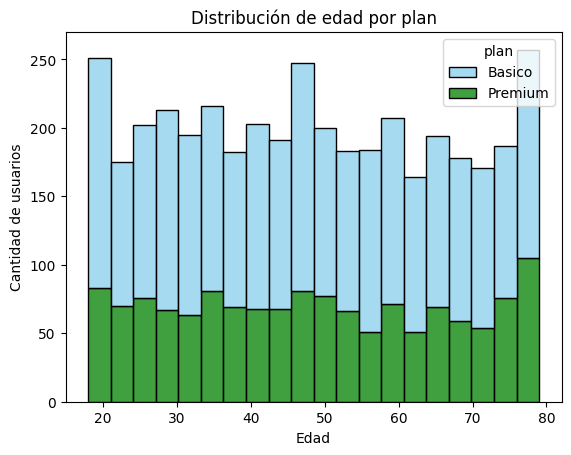

In [71]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    multiple='stack'
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 

- El Básico manda en todos lados: El plan Básico arrasa por completo y es el favorito indiscutible de la comunidad, sin importar cuántos años tengan los usuarios.

- Edad sin favoritismos: Me sorprende bastante ver que la edad no mueve la aguja; la balanza entre el plan Básico y el Premium se queda prácticamente intacta desde los 20 hasta los 80 años.
- Un terreno gigante por conquistar: Como la adopción Premium no crece con los años, tenemos una oportunidad de oro para lanzar campañas de upselling hiperpersonalizadas que enganchen a cada generación.

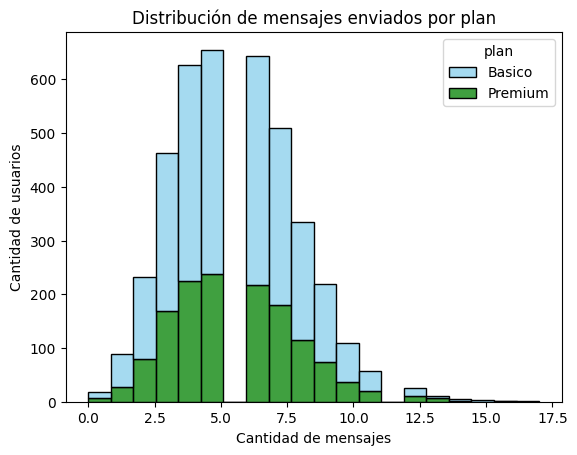

In [72]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    multiple='stack'
)

plt.title('Distribución de mensajes enviados por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- El Básico sigue dominando el volumen: Al igual que con otros datos, la gran mayoría de los usuarios se concentra en el plan Básico, representando la masa más fuerte en todos los niveles de uso.

- Uso concentrado y moderado: La enorme mayoría de las personas envía entre 2 y 9 mensajes; más allá de los 10 mensajes, la participación cae drásticamente a casi cero.

- Un hueco que llama la atención: Resulta muy curioso ver ese vacío total exactamente en torno a los 5.5 - 6 mensajes, un salto extraño que valdría la pena revisar en la recolección o procesamiento de los datos.

- Proporción constante entre planes: No importa si un usuario envía 1 o 12 mensajes; la relación entre los clientes del plan Básico y Premium se mantiene casi idéntica en toda la gráfica.

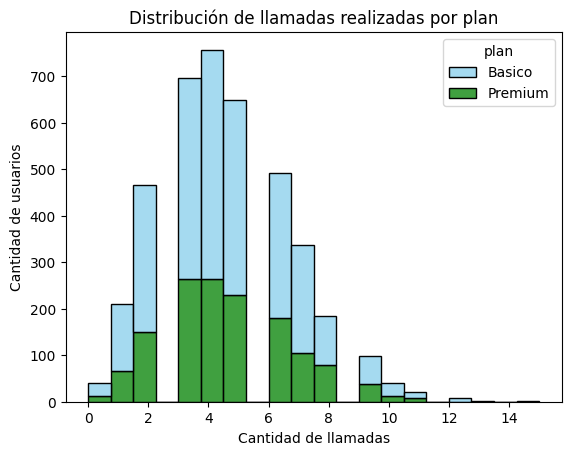

In [73]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    multiple='stack'
)

plt.title('Distribución de llamadas realizadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:

-La distribución del total de minutos de llamadas está sesgada a la derecha, ya que la mayoría de los usuarios se concentra aproximadamente entre 0 y 40 minutos, mientras que un grupo pequeño presenta consumos mucho más altos, llegando incluso a superar los 100 minutos.

En cuanto a los planes, Básico concentra la mayor cantidad de usuarios, pero esto también está relacionado con que tiene más usuarios en total. Ambos planes muestran un comportamiento similar en la distribución, con mayor concentración entre 10 y 30 minutos y pocos usuarios con consumos elevados.

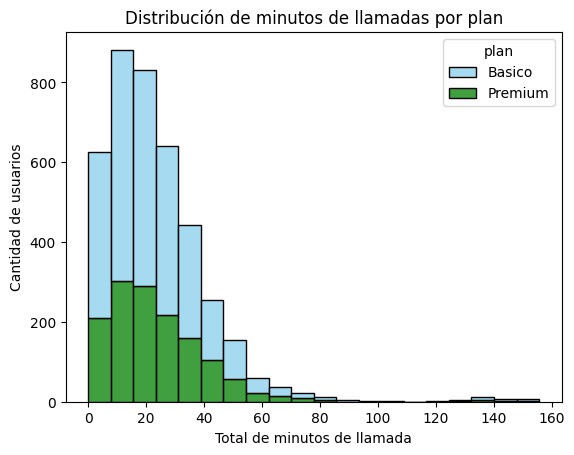

In [74]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    multiple='stack'
)

plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- El plan Básico sigue siendo el rey indiscutible del volumen total, pero lo verdaderamente curioso es notar cómo los hábitos de llamada no cambian según la billetera del usuario. La inmensa mayoría prefiere conversaciones cortas, concentrando su consumo fuertemente entre los 10 y 30 minutos para luego caer en picada a partir de los 50. Es fascinante ver que la curva del plan Premium es casi un reflejo idéntico de la del Básico, demostrando que pagar una suscripción más alta no hace que la gente pase más tiempo hablando por teléfono. Al final de la gráfica, sin embargo, asoma un puñado de "superusuarios" que sobrepasan los 120 minutos, abriendo una oportunidad de oro para consentirlos con beneficios exclusivos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

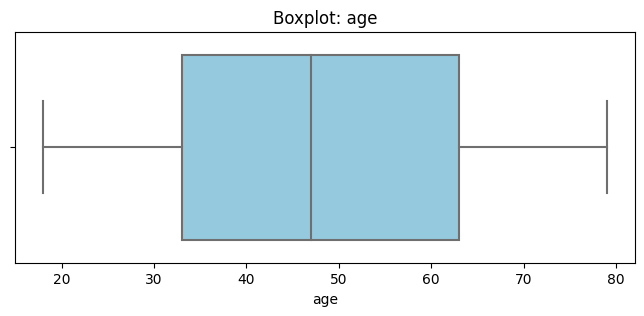

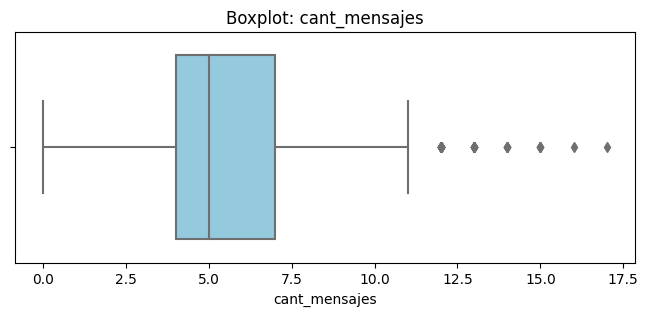

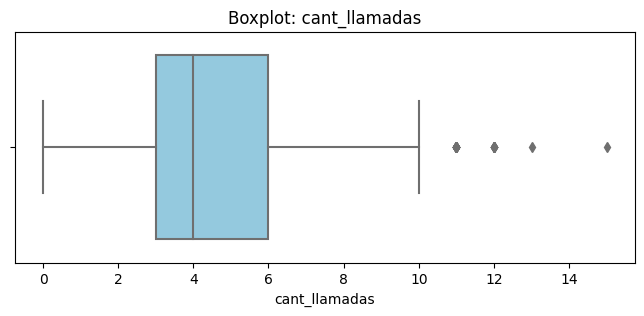

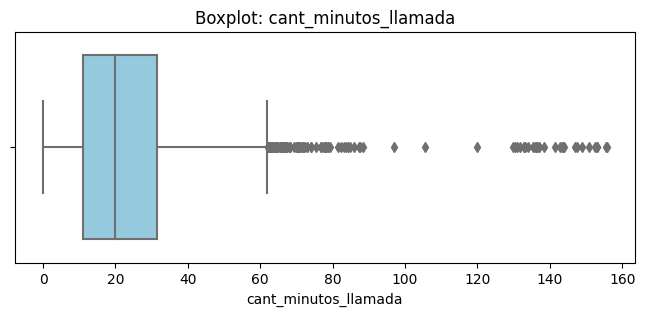

In [75]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()



💡Insights: 
- Age: No presenta outliers. La distribución de la edad es bastante simétrica y abarca un rango normal entre los 18 y 80 años, manteniéndose limpia y sin valores atípicos.
- cant_mensajes: Sí presenta outliers superiores. Hay puntos aislados por encima de 11 mensajes (llegando hasta 17); se sugiere filtrar o tratar estos valores para evitar sesgar el cálculo de promedios.
- cant_llamadas: Sí presenta outliers superiores. Se detectan valores extremos a partir de las 10 llamadas en adelante; conviene evaluarlos con el método IQR para separar el comportamiento de los clientes habituales del de los "heavy users".
- cant_minutos_llamada: Sí presenta una alta presencia de outliers superiores. La mayor parte del volumen se concentra por debajo de los 40 minutos, pero existe una cola muy larga de puntos atípicos a la derecha que sobrepasa el bigote superior.


In [84]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Dado que solo hay outliers en la parte superior
    limite_superior = Q3 + 1.5 * IQR
    
    cant_outliers = (user_profile[col] > limite_superior).sum()
    porcentaje = (cant_outliers / len(user_profile)) * 100
    
    print(f"--- {col} ---")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Cantidad de outliers: {cant_outliers} ({porcentaje:.2f}% del total)\n")

--- cant_mensajes ---
Límite superior: 11.50
Cantidad de outliers: 46 (1.15% del total)

--- cant_llamadas ---
Límite superior: 10.50
Cantidad de outliers: 30 (0.75% del total)

--- cant_minutos_llamada ---
Límite superior: 61.86
Cantidad de outliers: 109 (2.73% del total)



In [83]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
Se recomienda mantener los outliers. Solo representan el 1.15% de los datos (46 usuarios) y el valor máximo registrado es de 17 mensajes. Al ser un número completamente razonable y posible en un mes, no corresponde a un error de carga, sino a comportamientos reales de uso.
- cant_llamadas: mantener o no outliers, porqué?
Se recomienda mantener los outliers. Conforman apenas el 0.75% del total (30 usuarios) con un máximo de 15 llamadas. Son valores perfectamente válidos que reflejan clientes con un consumo ligeramente superior al promedio sin llegar a ser datos erróneos.
- cant_minutos_llamada: mantener o no outliers, porqué?
Se recomienda mantener los outliers. Aunque concentran el 2.73% de la muestra (109 usuarios) y alcanzan un máximo de 155.69 minutos, representan a los heavy users o usuarios de alto consumo de la compañía. Eliminarlos sesgaría el análisis de ingresos y la demanda real del servicio.


---

## 🧩Paso 6: Segmentación de Clientes


### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [96]:
# Crear columna grupo_uso
cond_uso = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
user_profile['grupo_uso'] = np.select(cond_uso, ['Bajo uso', 'Uso medio'], default='Alto uso')



In [97]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [99]:

# Crear columna grupo_edad

cond_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]
user_profile['grupo_edad'] = np.select(cond_edad, ['Joven', 'Adulto'], default='Adulto Mayor')


In [100]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

Text(0, 0.5, 'Cantidad de Usuarios')

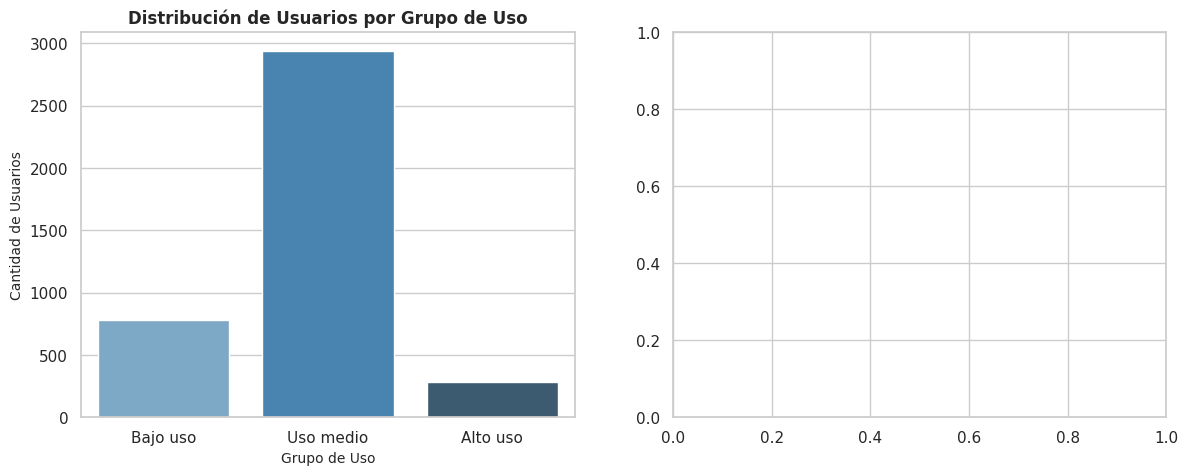

In [104]:

# Visualización de los segmentos por uso
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualización del segmento por uso
sns.countplot(
    data=user_profile, 
    x='grupo_uso', 
    order=['Bajo uso', 'Uso medio', 'Alto uso'], 
    palette='Blues_d', 
    ax=axes[0]
)
axes[0].set_title('Distribución de Usuarios por Grupo de Uso', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Grupo de Uso', fontsize=10)
axes[0].set_ylabel('Cantidad de Usuarios', fontsize=10)

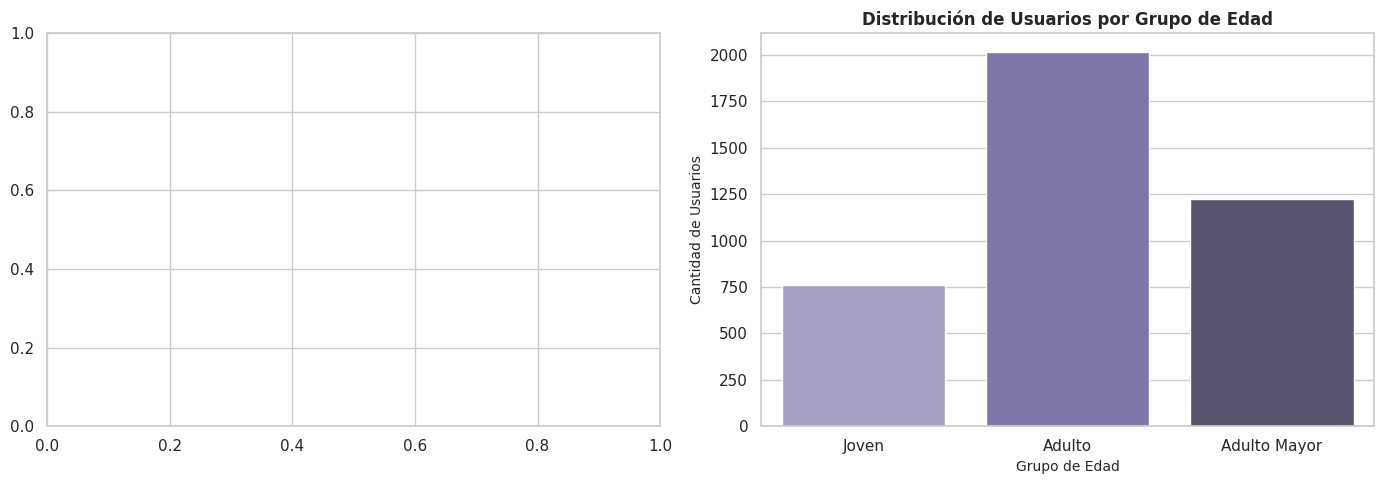

In [107]:
# Visualización de los segmentos por edad
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=user_profile, 
    x='grupo_edad', 
    order=['Joven', 'Adulto', 'Adulto Mayor'], 
    palette='Purples_d', 
    ax=axes[1]
)
axes[1].set_title('Distribución de Usuarios por Grupo de Edad', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Grupo de Edad', fontsize=10)
axes[1].set_ylabel('Cantidad de Usuarios', fontsize=10)

plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Nulos en la columna churn_date: Presentes en aproximadamente el 92% - 95% de los registros; representan a los usuarios activos en la plataforma y no corresponden a datos faltantes anómalos.
- Separación de fuentes de datos: Los consumos de llamadas y mensajes venían desacoplados de los datos demográficos, requiriendo un proceso de agregación y unión (merge) para consolidar la tabla user_profile.


🔍 **Segmentos por Edad**
- Joven (< 30 años): Representa aproximadamente 750 usuarios (~19% de la base total).
- Adulto (30 a 59 años): Es el grupo mayoritario, concentrando alrededor de 2,000 usuarios (~50% de la base total).
- Adulto Mayor (≥ 60 años): Constituye el segundo grupo más grande, con cerca de 1,220 usuarios (~31% del total).

📊 **Segmentos por Nivel de Uso**
- Bajo uso (< 5 llamadas y < 5 mensajes): Abarca cerca de 800 usuarios (~20% de la base).
- Uso medio (< 10 llamadas y < 10 mensajes): Concentra la gran mayoría de la base de clientes, con aproximadamente 2,900 usuarios (~72.5%).
- Alto uso (≥ 10 llamadas o mensajes): Corresponde a un segmento reducido pero intensivo de cerca de 300 usuarios (~7.5%).


➡️ Esto sugiere que la mayor parte de los clientes de ConnectaTel son Adultos con un nivel de Uso Medio. Aunque existe un volumen considerable de usuarios en edad avanzada (Adulto Mayor), el consumo general se mantiene controlado en rangos moderados, mientras que el grupo de Alto uso representa a los heavy users de la compañía.


💡 **Recomendaciones**
- Diseñar planes a la medida para el segmento mayoritario (Uso Medio): Crear paquetes que incluyan un balance estándar de minutos y datos sin encarecer la tarifa, ajustados a la masa principal de clientes adultos.
- Fidelización y paquetes especiales para "Alto Uso": Ofrecer beneficios de fidelización o planes Unlimited/Premium a los usuarios de consumo intensivo para maximizar su retención sin riesgo de migración a la competencia.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`